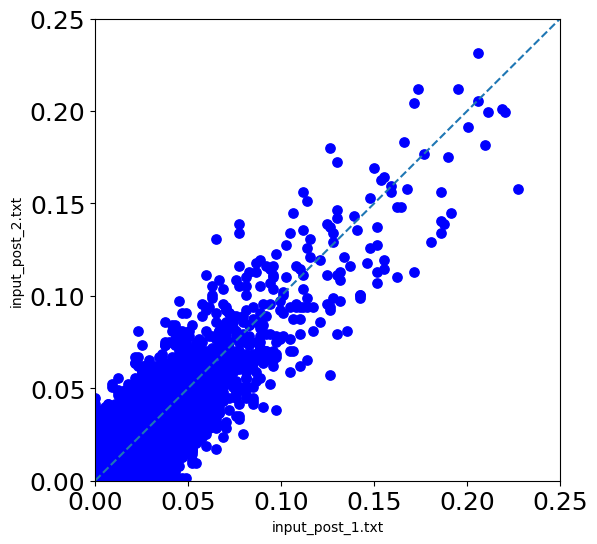

In [1]:
!pip install scipy matplotlib numpy pandas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats

def zscore(array):
    p_i = 1 / len(array)
    po_list = array / sum(array)
    zscore_list = (po_list / p_i - 1) * pow(p_i / (1 - p_i), 0.5)
    return zscore_list

def generate_z_score(file):
    data = pd.read_table(file, sep=",")
    xdata_post = np.array(data["Counts"])
    zscore_list = zscore(xdata_post)
    return zscore_list

def compare_z(filea, fileb, xlim=None, ylim=None, width=10, height=6):
    filea_z = generate_z_score(filea)
    fileb_z = generate_z_score(fileb)
    
    data_post = pd.read_csv(fileb, sep=",")
    new_df = pd.DataFrame()
    new_df["Pre-selection"] = filea_z
    new_df["Post-selection"] = fileb_z
    new_df["cycle_1_lane"] = data_post["CodeB"]
    new_df["cycle_2_lane"] = data_post["CodeC"]
    new_df["cycle_3_lane"] = data_post["CodeD"]
    
    xdata = filea_z
    ydata = fileb_z
    
    plt.figure(figsize=(width, height))  # Set figure size
    plt.scatter(xdata, ydata, s=45, c="b")  # Set dot size
    
    x = np.arange(0, 2, 0.01)
    y = [t for t in x]
    plt.plot(x, y, label="y=x", linestyle="--")
    
    plt.xlabel(filea)
    plt.ylabel(fileb)

    # Set axis limits if provided
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)

    # Enlarging tick fonts
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    
    plt.savefig(f"output_z_{filea.split('.txt')[0]}_{fileb.split('.txt')[0]}.png")
    
    # For reproducible enriched compounds in the post data of two selections
    new_df["zscore+"] = fileb_z + filea_z
    file_sort = new_df.sort_values(by="zscore+", axis=0).copy()
    file_sort = file_sort[-50:].copy()
    file_sort.to_csv(f"output_z_{filea.split('.txt')[0]}_{fileb.split('.txt')[0]}_sum50.csv", index=False)

# Example usage with adjustable axis limits, figure size, and dot size
compare_z(filea="input_post_1.txt", fileb="input_post_2.txt", xlim=(0, 0.25), ylim=(0, 0.25),
          width=6, height=6)